## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from skfda import FDataGrid
from skfda.preprocessing.dim_reduction import FPCA
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.representation.basis import BSplineBasis

sys.path.insert(0, str(Path('..') / 'src'))
from classify_loader import load_manifest, build_dataset

plt.style.use('../imagestyle.mplstyle')

DATA_DIR     = Path('..') / 'Kural_Dataset'
EDF_DIR      = DATA_DIR / 'Recordings'
MANIFEST_CSV = DATA_DIR / 'eeg_summary.csv'

## 2. Load Manifest and Filter

In [2]:
manifest = load_manifest(MANIFEST_CSV)
print(f'Usable recordings: {len(manifest)}')

print('\nClass counts (label_binary):')
print(manifest['label_binary'].value_counts().rename({0: 'Non-epileptic (0)', 1: 'Epileptic (1)'}).to_string())

print('\nCertainty counts:')
print(manifest['certainty'].value_counts().to_string())

Usable recordings: 100

Class counts (label_binary):
label_binary
Epileptic (1)        54
Non-epileptic (0)    46

Certainty counts:
certainty
negative            46
unclear_positive    32
clear_positive      22


## 3. Build Dataset

In [3]:
fd, y, cert, half_width_s = build_dataset(manifest, EDF_DIR)

t      = fd.grid_points[0]
domain = fd.domain_range[0]
n      = len(y)

print(f'FDataGrid shape : {fd.data_matrix.shape}')
print(f'Half-width      : {half_width_s:.4f} s  (total window: {2 * half_width_s:.4f} s)')
assert len({fd.data_matrix[i].shape[0] for i in range(n)}) == 1, 'Mismatched curve lengths'
print('All curves equal length: True')

FDataGrid shape : (100, 2328, 1)
Half-width      : 2.3281 s  (total window: 4.6562 s)
All curves equal length: True


## 4. Inspect the Curves

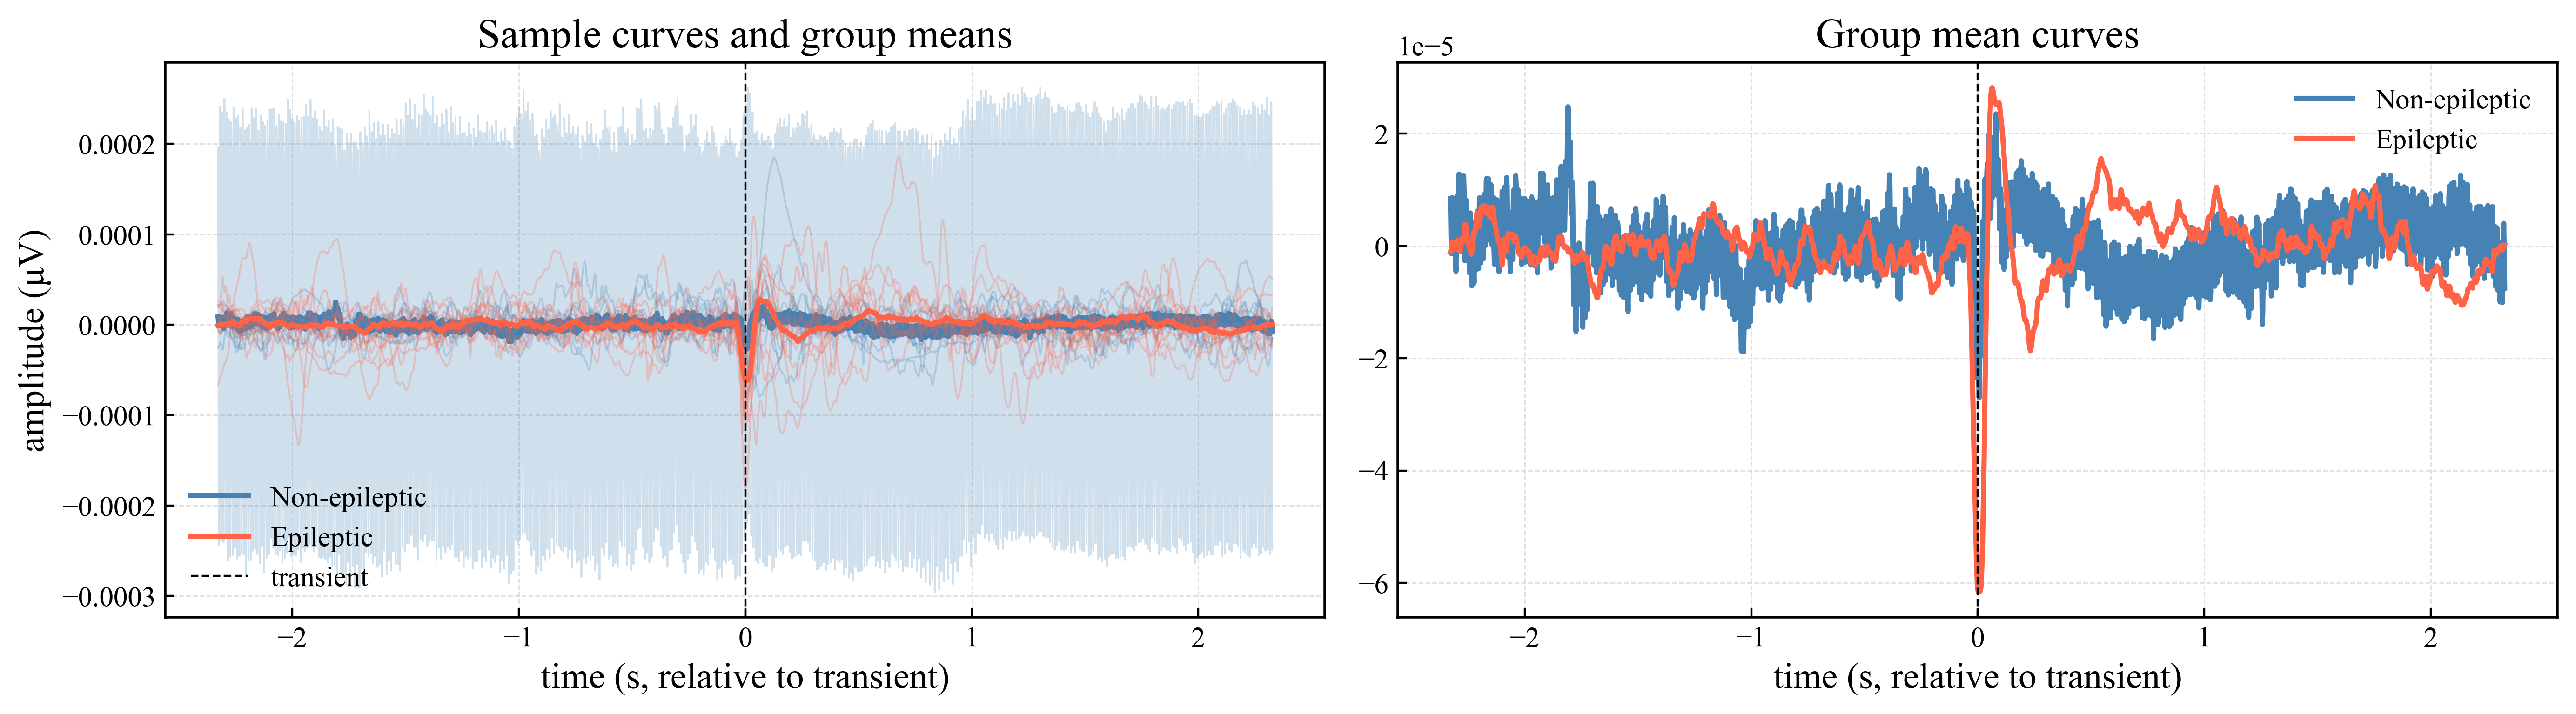

In [4]:
colors     = {0: 'steelblue', 1: 'tomato'}
label_str  = {0: 'Non-epileptic', 1: 'Epileptic'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for cls in [0, 1]:
    idx = np.where(y == cls)[0][:10]
    for i in idx:
        axes[0].plot(t, fd.data_matrix[i, :, 0], color=colors[cls], alpha=0.25, linewidth=0.7)
    mean_curve = fd.data_matrix[y == cls, :, 0].mean(axis=0)
    axes[0].plot(t, mean_curve, color=colors[cls], linewidth=2, label=label_str[cls])

axes[0].axvline(0, color='k', linestyle='--', linewidth=0.8, label='transient')
axes[0].set_xlabel('time (s, relative to transient)')
axes[0].set_ylabel('amplitude (\u03bcV)')
axes[0].set_title('Sample curves and group means')
axes[0].legend()

for cls in [0, 1]:
    mean_curve = fd.data_matrix[y == cls, :, 0].mean(axis=0)
    axes[1].plot(t, mean_curve, color=colors[cls], linewidth=2, label=label_str[cls])
axes[1].axvline(0, color='k', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('time (s, relative to transient)')
axes[1].set_title('Group mean curves')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Smoothing (Exploratory)

> **Exploratory only** — smoother and FPCA here are fitted on all 100 curves to pick hyperparameters and sanity-check. The evaluated model (Stage 7+) re-fits these steps inside the pipeline per fold, so no leakage enters the reported metrics.

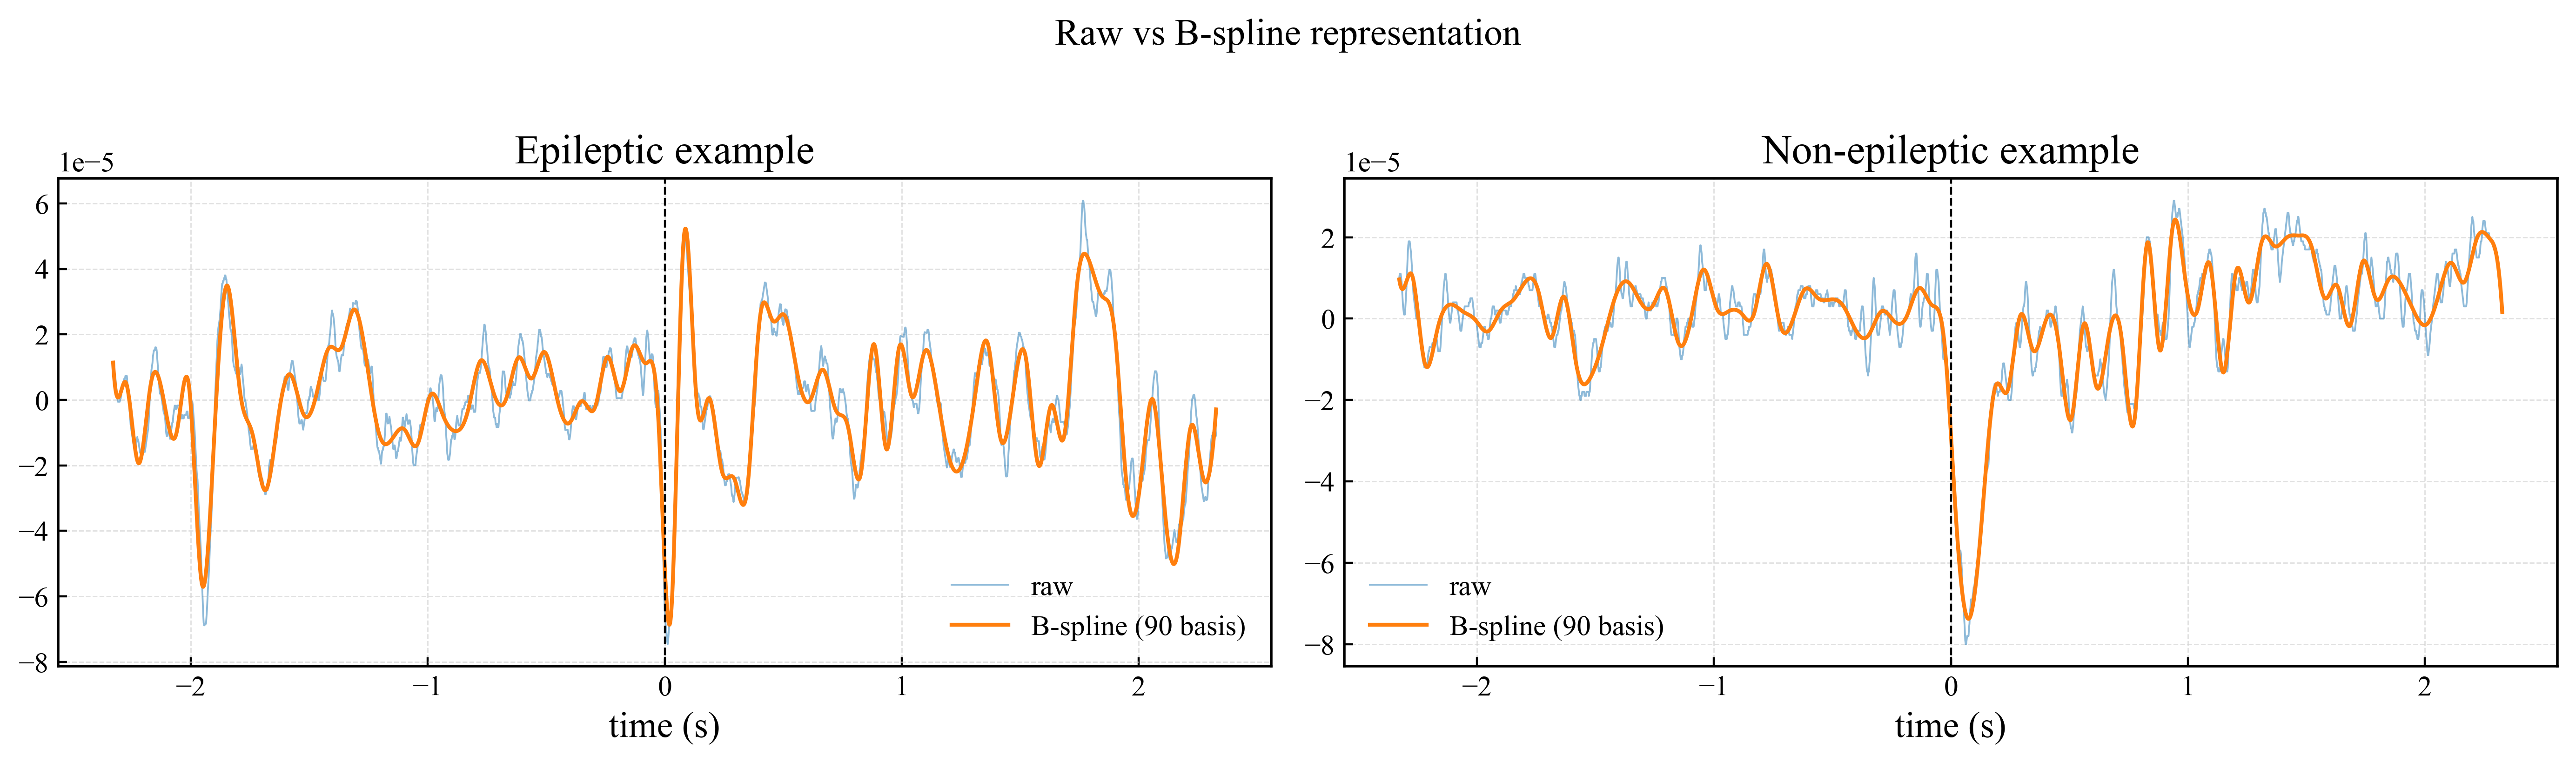

In [5]:
N_BASIS = 90

basis_expl    = BSplineBasis(domain_range=domain, n_basis=N_BASIS, order=4)
smoother_expl = BasisSmoother(basis_expl, return_basis=True)
fd_smooth     = smoother_expl.fit_transform(fd)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, cls in zip(axes, [1, 0]):
    idx         = np.where(y == cls)[0][0]
    smooth_vals = fd_smooth[idx].to_grid(grid_points=t).data_matrix[0, :, 0]
    ax.plot(t, fd.data_matrix[idx, :, 0], alpha=0.5, linewidth=0.7, label='raw')
    ax.plot(t, smooth_vals, linewidth=1.5, label=f'B-spline ({N_BASIS} basis)')
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_title(f"{'Epileptic' if cls == 1 else 'Non-epileptic'} example")
    ax.set_xlabel('time (s)')
    ax.legend()

plt.suptitle('Raw vs B-spline representation', y=1.02)
plt.tight_layout()
plt.show()

## 6. FPCA (Exploratory)

Variance explained per component:
  PC 1: 0.256  (cumulative: 0.256)
  PC 2: 0.129  (cumulative: 0.386)
  PC 3: 0.122  (cumulative: 0.507)
  PC 4: 0.085  (cumulative: 0.592)
  PC 5: 0.051  (cumulative: 0.643) <-- pipeline uses first 5
  PC 6: 0.039  (cumulative: 0.683)
  PC 7: 0.031  (cumulative: 0.714)
  PC 8: 0.026  (cumulative: 0.740)
  PC 9: 0.022  (cumulative: 0.761)
  PC10: 0.019  (cumulative: 0.781)


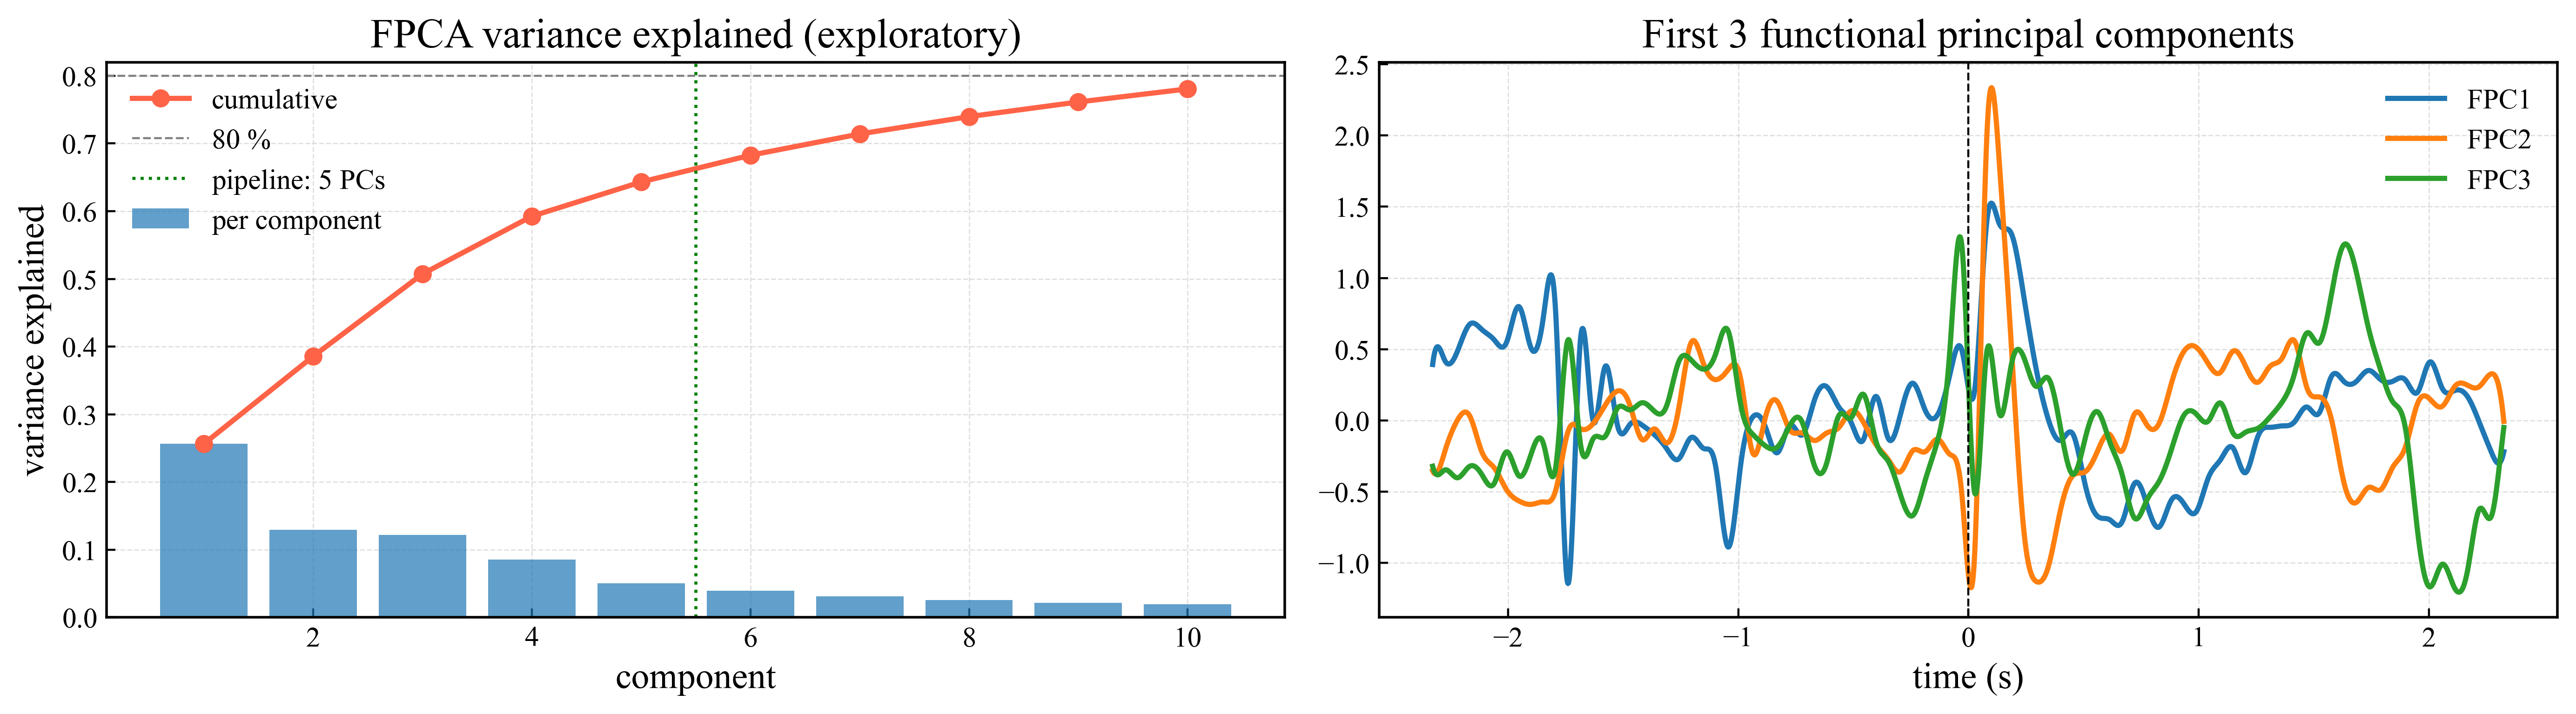

In [6]:
N_COMPONENTS = 5

fpca_expl = FPCA(n_components=10)
fpca_expl.fit(fd_smooth)
var_exp = fpca_expl.explained_variance_ratio_
cum_var = np.cumsum(var_exp)

print('Variance explained per component:')
for i, (v, cv) in enumerate(zip(var_exp, cum_var), 1):
    marker = ' <-- pipeline uses first 5' if i == N_COMPONENTS else ''
    print(f'  PC{i:2d}: {v:.3f}  (cumulative: {cv:.3f}){marker}')

comp_grid = fpca_expl.components_.to_grid(grid_points=t).data_matrix  # (10, 2328, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, 11), var_exp, alpha=0.7, label='per component')
axes[0].plot(range(1, 11), cum_var, 'o-', color='tomato', label='cumulative')
axes[0].axhline(0.8, color='gray', linestyle='--', linewidth=0.8, label='80 %')
axes[0].axvline(N_COMPONENTS + 0.5, color='green', linestyle=':', linewidth=1.2,
                label=f'pipeline: {N_COMPONENTS} PCs')
axes[0].set_xlabel('component')
axes[0].set_ylabel('variance explained')
axes[0].set_title('FPCA variance explained (exploratory)')
axes[0].legend()

for i in range(3):
    axes[1].plot(t, comp_grid[i, :, 0], label=f'FPC{i + 1}')
axes[1].axvline(0, color='k', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('time (s)')
axes[1].set_title('First 3 functional principal components')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Build the Pipeline

In [7]:
pipe = Pipeline([
    ('smooth', BasisSmoother(
        BSplineBasis(domain_range=domain, n_basis=N_BASIS, order=4),
        return_basis=True,
    )),
    ('fpca', FPCA(n_components=N_COMPONENTS)),
    ('lr',   LogisticRegression(max_iter=1000)),
])
print(pipe)

Pipeline(steps=[('smooth',
                 BasisSmoother(basis=BSplineBasis(domain_range=((-2.328, 2.326),), n_basis=90, order=4, knots=(-2.328, -2.2745057471264367, -2.2210114942528736, -2.16751724137931, -2.114022988505747, -2.0605287356321837, -2.0070344827586206, -1.9535402298850573, -1.9000459770114941, -1.8465517241379308, -1.7930574712643677, -1.7395632183908045, -1.6860689...701154, 1.6305747126436785, 1.6840689655172416, 1.7375632183908052, 1.7910574712643679, 1.8445517241379314, 1.898045977011495, 1.9515402298850577, 2.0050344827586213, 2.058528735632184, 2.1120229885057475, 2.165517241379311, 2.219011494252874, 2.2725057471264374, 2.326)),
                               return_basis=True)),
                ('fpca', FPCA(n_components=5)),
                ('lr', LogisticRegression(max_iter=1000))])


## 8. Cross-Validation Setup

In [8]:
N_REPEATS = 20
N_FOLDS   = 5

# CV is stratified on the 3-way certainty label so every fold carries
# clear/unclear/negative proportionally; the pipeline trains on binary y.
# RepeatedStratifiedKFold cannot split on one variable and train on another,
# so we drive the loop manually.

def compute_metrics(y_true, probs, cert, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        'auc':          roc_auc_score(y_true, probs),
        'specificity':  np.mean(preds[cert == 'negative']          == 0),
        'sens_clear':   np.mean(preds[cert == 'clear_positive']    == 1),
        'sens_unclear': np.mean(preds[cert == 'unclear_positive']  == 1),
    }

## 9. Reference Baselines

In [9]:
# Baseline 1: majority-class predictor
# Outputs the training class frequency as the probability for every test point.

# Baseline 2: logistic regression on peak-to-peak amplitude
X_scalar = np.ptp(fd.data_matrix[:, :, 0], axis=1, keepdims=True)  # (100, 1), units: V (MNE convention)

scalar_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=1000)),
])

print(f'Scalar feature (peak-to-peak): shape={X_scalar.shape}, '
      f'range=[{X_scalar.min() * 1e6:.1f}, {X_scalar.max() * 1e6:.1f}] μV'
      f'  (stored in V, MNE convention)')

Scalar feature (peak-to-peak): shape=(100, 1), range=[70.0, 1319.9] μV  (stored in V, MNE convention)


## 10. Run Evaluation

In [10]:
repeat_results = []                                                           # list[dict], one per repeat
avg_probs      = {m: np.zeros(n) for m in ['fda', 'majority', 'scalar']}    # for stage 12 plot

for repeat in range(N_REPEATS):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=repeat)
    oof = {m: np.zeros(n) for m in ['fda', 'majority', 'scalar']}

    for train_idx, test_idx in skf.split(np.arange(n), cert):
        fd_tr, fd_te = fd[train_idx], fd[test_idx]
        y_tr         = y[train_idx]
        X_tr, X_te   = X_scalar[train_idx], X_scalar[test_idx]

        pipe.fit(fd_tr, y_tr)
        oof['fda'][test_idx] = pipe.predict_proba(fd_te)[:, 1]

        oof['majority'][test_idx] = np.mean(y_tr)          # training prevalence as prob

        scalar_pipe.fit(X_tr, y_tr)
        oof['scalar'][test_idx] = scalar_pipe.predict_proba(X_te)[:, 1]

    repeat_results.append({m: compute_metrics(y, oof[m], cert) for m in oof})
    for m in avg_probs:
        avg_probs[m] += oof[m]

for m in avg_probs:
    avg_probs[m] /= N_REPEATS

print(f'Done: {N_REPEATS} repeats x {N_FOLDS} folds = {N_REPEATS * N_FOLDS} fits per model')

Done: 20 repeats x 5 folds = 100 fits per model


## 11. Results

In [11]:
metric_names = {
    'auc':          'AUC',
    'specificity':  'Specificity (negatives)',
    'sens_clear':   'Sensitivity \u2014 clear positives',
    'sens_unclear': 'Sensitivity \u2014 unclear positives',
}
model_names = {
    'fda':      'FDA pipeline',
    'majority': 'Majority class',
    'scalar':   'Scalar LR (peak-to-peak)',
}

rows = []
for model in ['fda', 'majority', 'scalar']:
    for metric in ['auc', 'specificity', 'sens_clear', 'sens_unclear']:
        vals = [r[model][metric] for r in repeat_results]
        rows.append({
            'Model':  model_names[model],
            'Metric': metric_names[metric],
            'Mean':   np.mean(vals),
            'p10':    np.percentile(vals, 10),
            'p90':    np.percentile(vals, 90),
        })

results_df = pd.DataFrame(rows)
results_df['Mean (p10\u2013p90)'] = results_df.apply(
    lambda r: f"{r['Mean']:.3f}  ({r['p10']:.3f}\u2013{r['p90']:.3f})", axis=1
)
pivot = results_df.pivot(index='Metric', columns='Model', values='Mean (p10\u2013p90)')
pivot = pivot[list(model_names.values())]
pivot.index.name  = None
pivot.columns.name = None
display(pivot)

,FDA pipeline,Majority class,Scalar LR (peak-to-peak)
AUC,0.574 (0.549–0.599),0.484 (0.484–0.484),0.719 (0.696–0.746)
Sensitivity — clear positives,1.000 (1.000–1.000),1.000 (1.000–1.000),0.900 (0.864–0.955)
Sensitivity — unclear positives,1.000 (1.000–1.000),1.000 (1.000–1.000),0.881 (0.844–0.909)
Specificity (negatives),0.000 (0.000–0.000),0.000 (0.000–0.000),0.366 (0.304–0.417)


## 12. Probability Distribution by Certainty

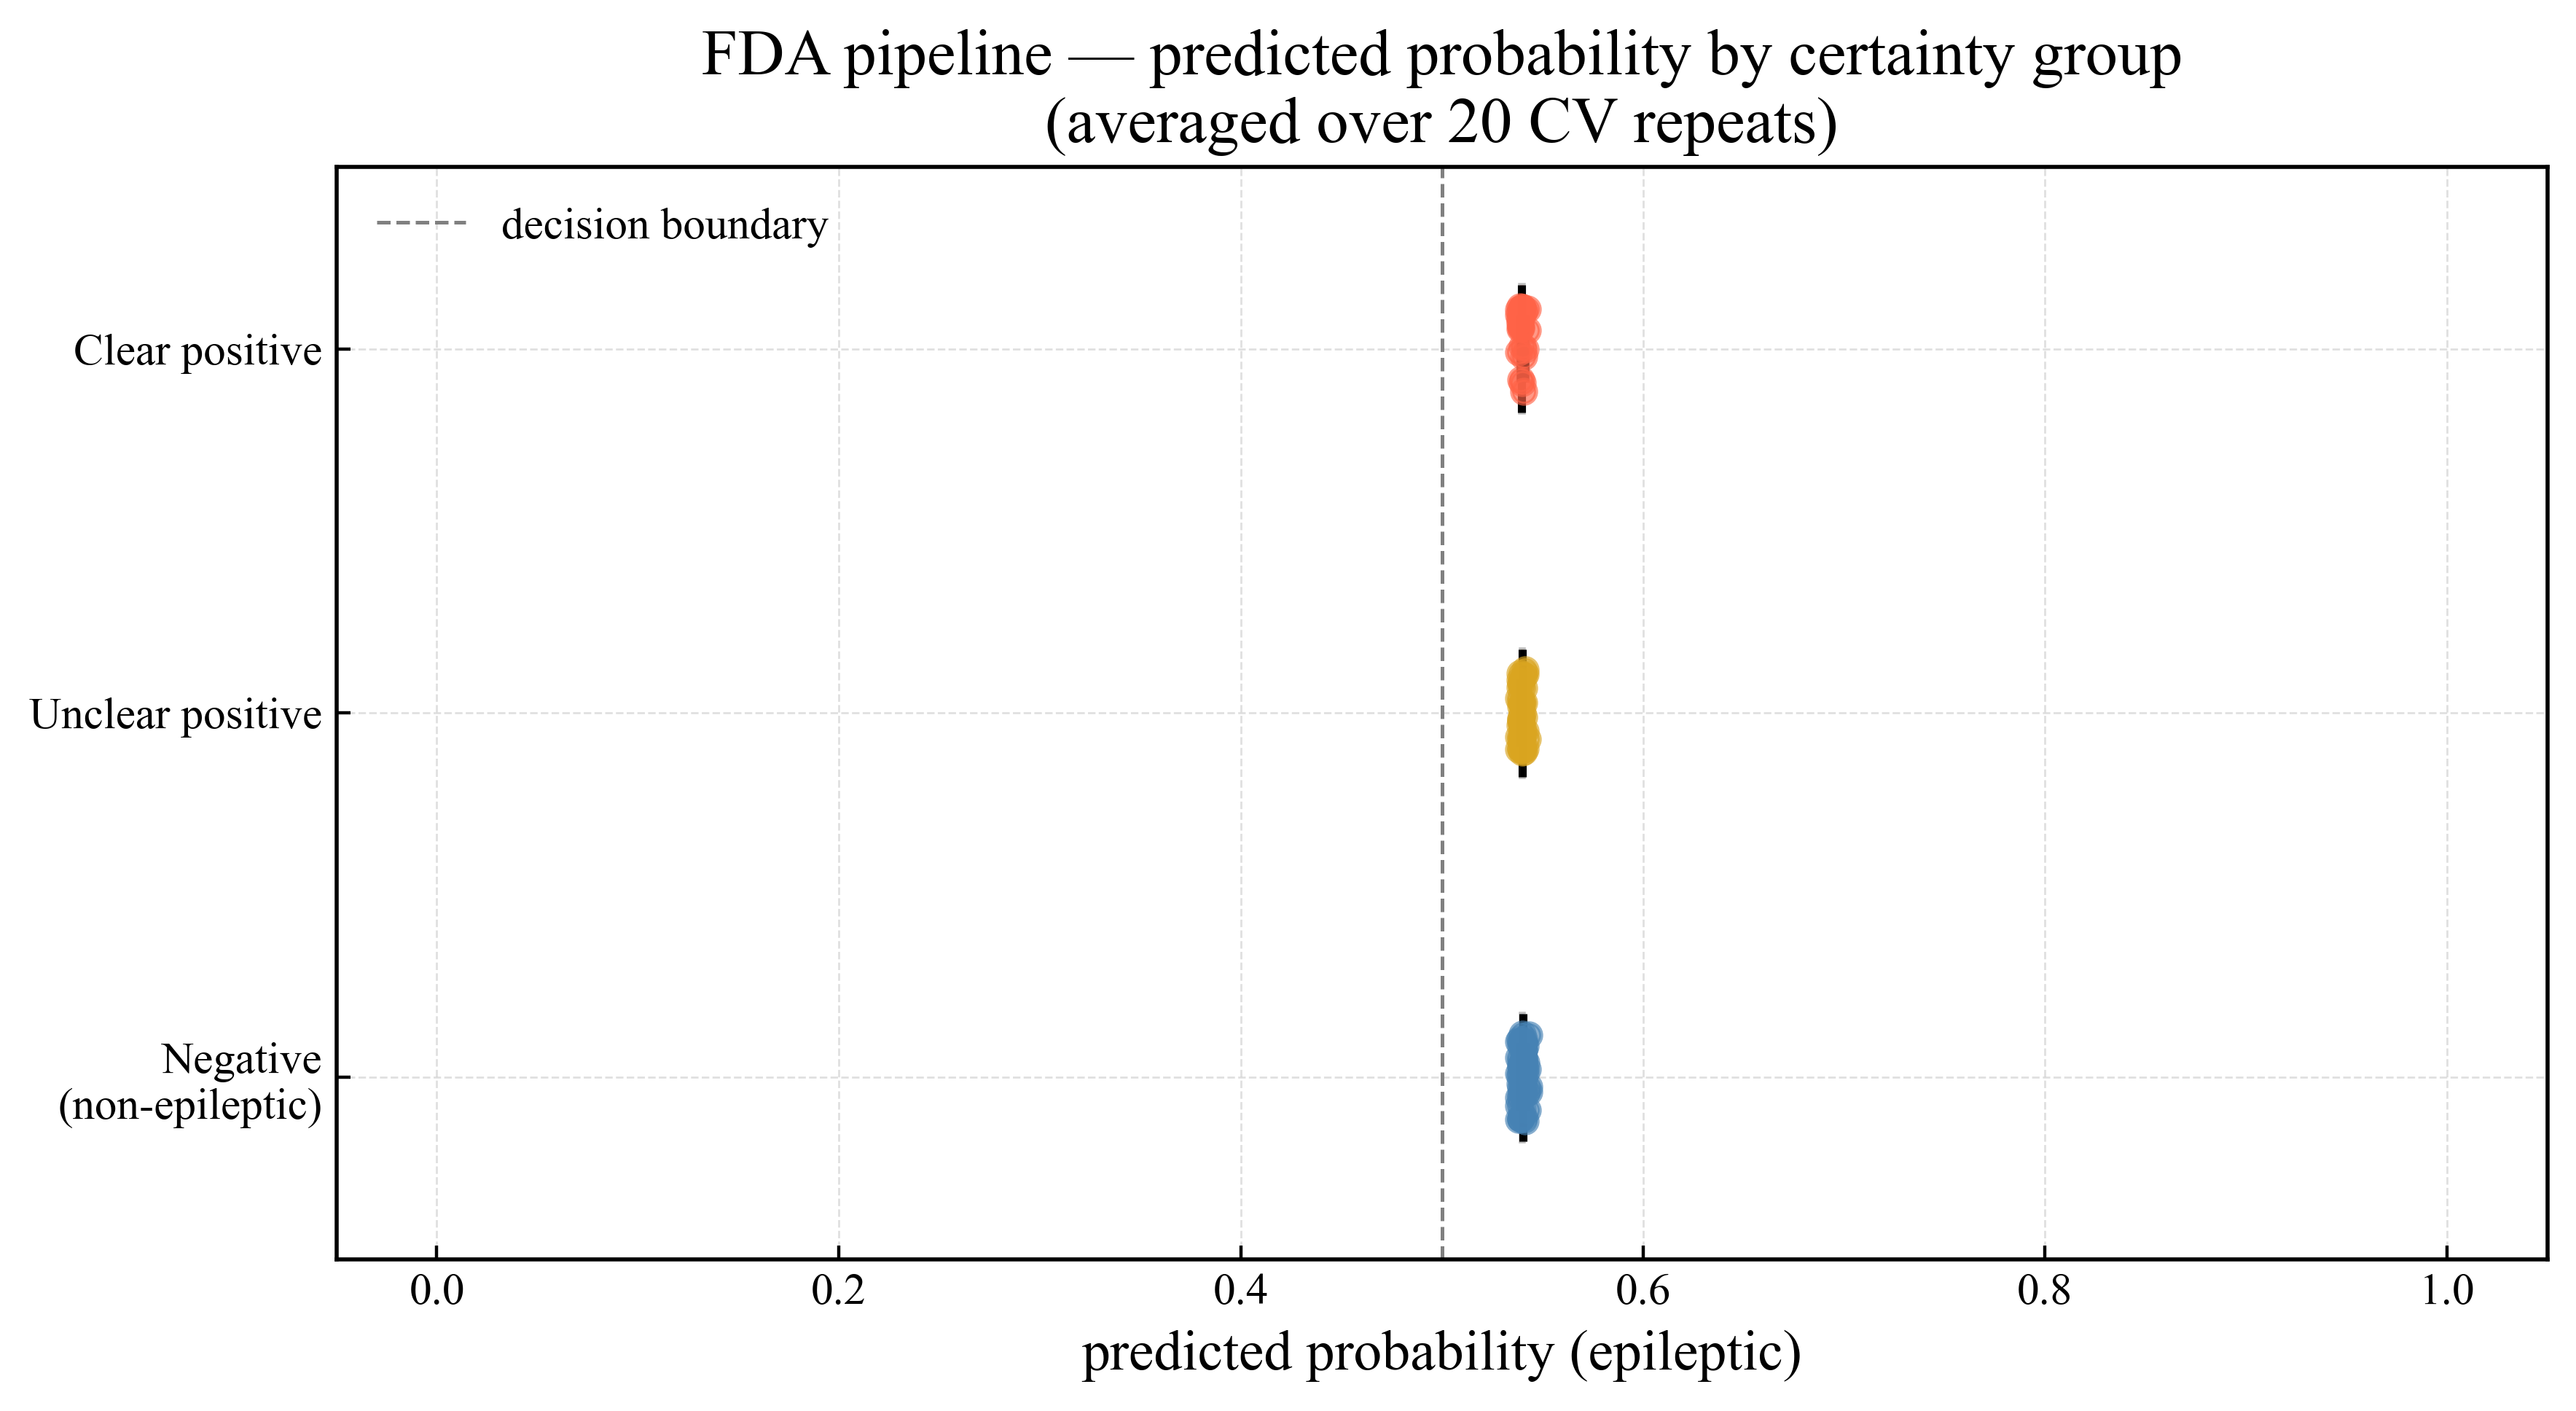

In [12]:
cert_order   = ['negative', 'unclear_positive', 'clear_positive']
cert_colors  = {'negative': 'steelblue', 'unclear_positive': 'goldenrod', 'clear_positive': 'tomato'}
cert_display = {
    'negative':          'Negative\n(non-epileptic)',
    'unclear_positive':  'Unclear positive',
    'clear_positive':    'Clear positive',
}

fig, ax = plt.subplots(figsize=(9, 5))
rng = np.random.default_rng(0)

for i, cert_val in enumerate(cert_order):
    mask   = cert == cert_val
    probs  = avg_probs['fda'][mask]
    color  = cert_colors[cert_val]
    jitter = rng.uniform(-0.12, 0.12, mask.sum())
    ax.scatter(probs, np.full(mask.sum(), i) + jitter,
               alpha=0.65, color=color, s=35, zorder=3)
    ax.boxplot(
        probs, positions=[i], vert=False, widths=0.35, patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.25),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
        flierprops=dict(marker=''),
        zorder=2,
    )

ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.9, label='decision boundary')
ax.set_yticks(range(3))
ax.set_yticklabels([cert_display[c] for c in cert_order])
ax.set_xlabel('predicted probability (epileptic)')
ax.set_xlim(-0.05, 1.05)
ax.set_title('FDA pipeline \u2014 predicted probability by certainty group\n(averaged over 20 CV repeats)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 13. Confusion Matrices

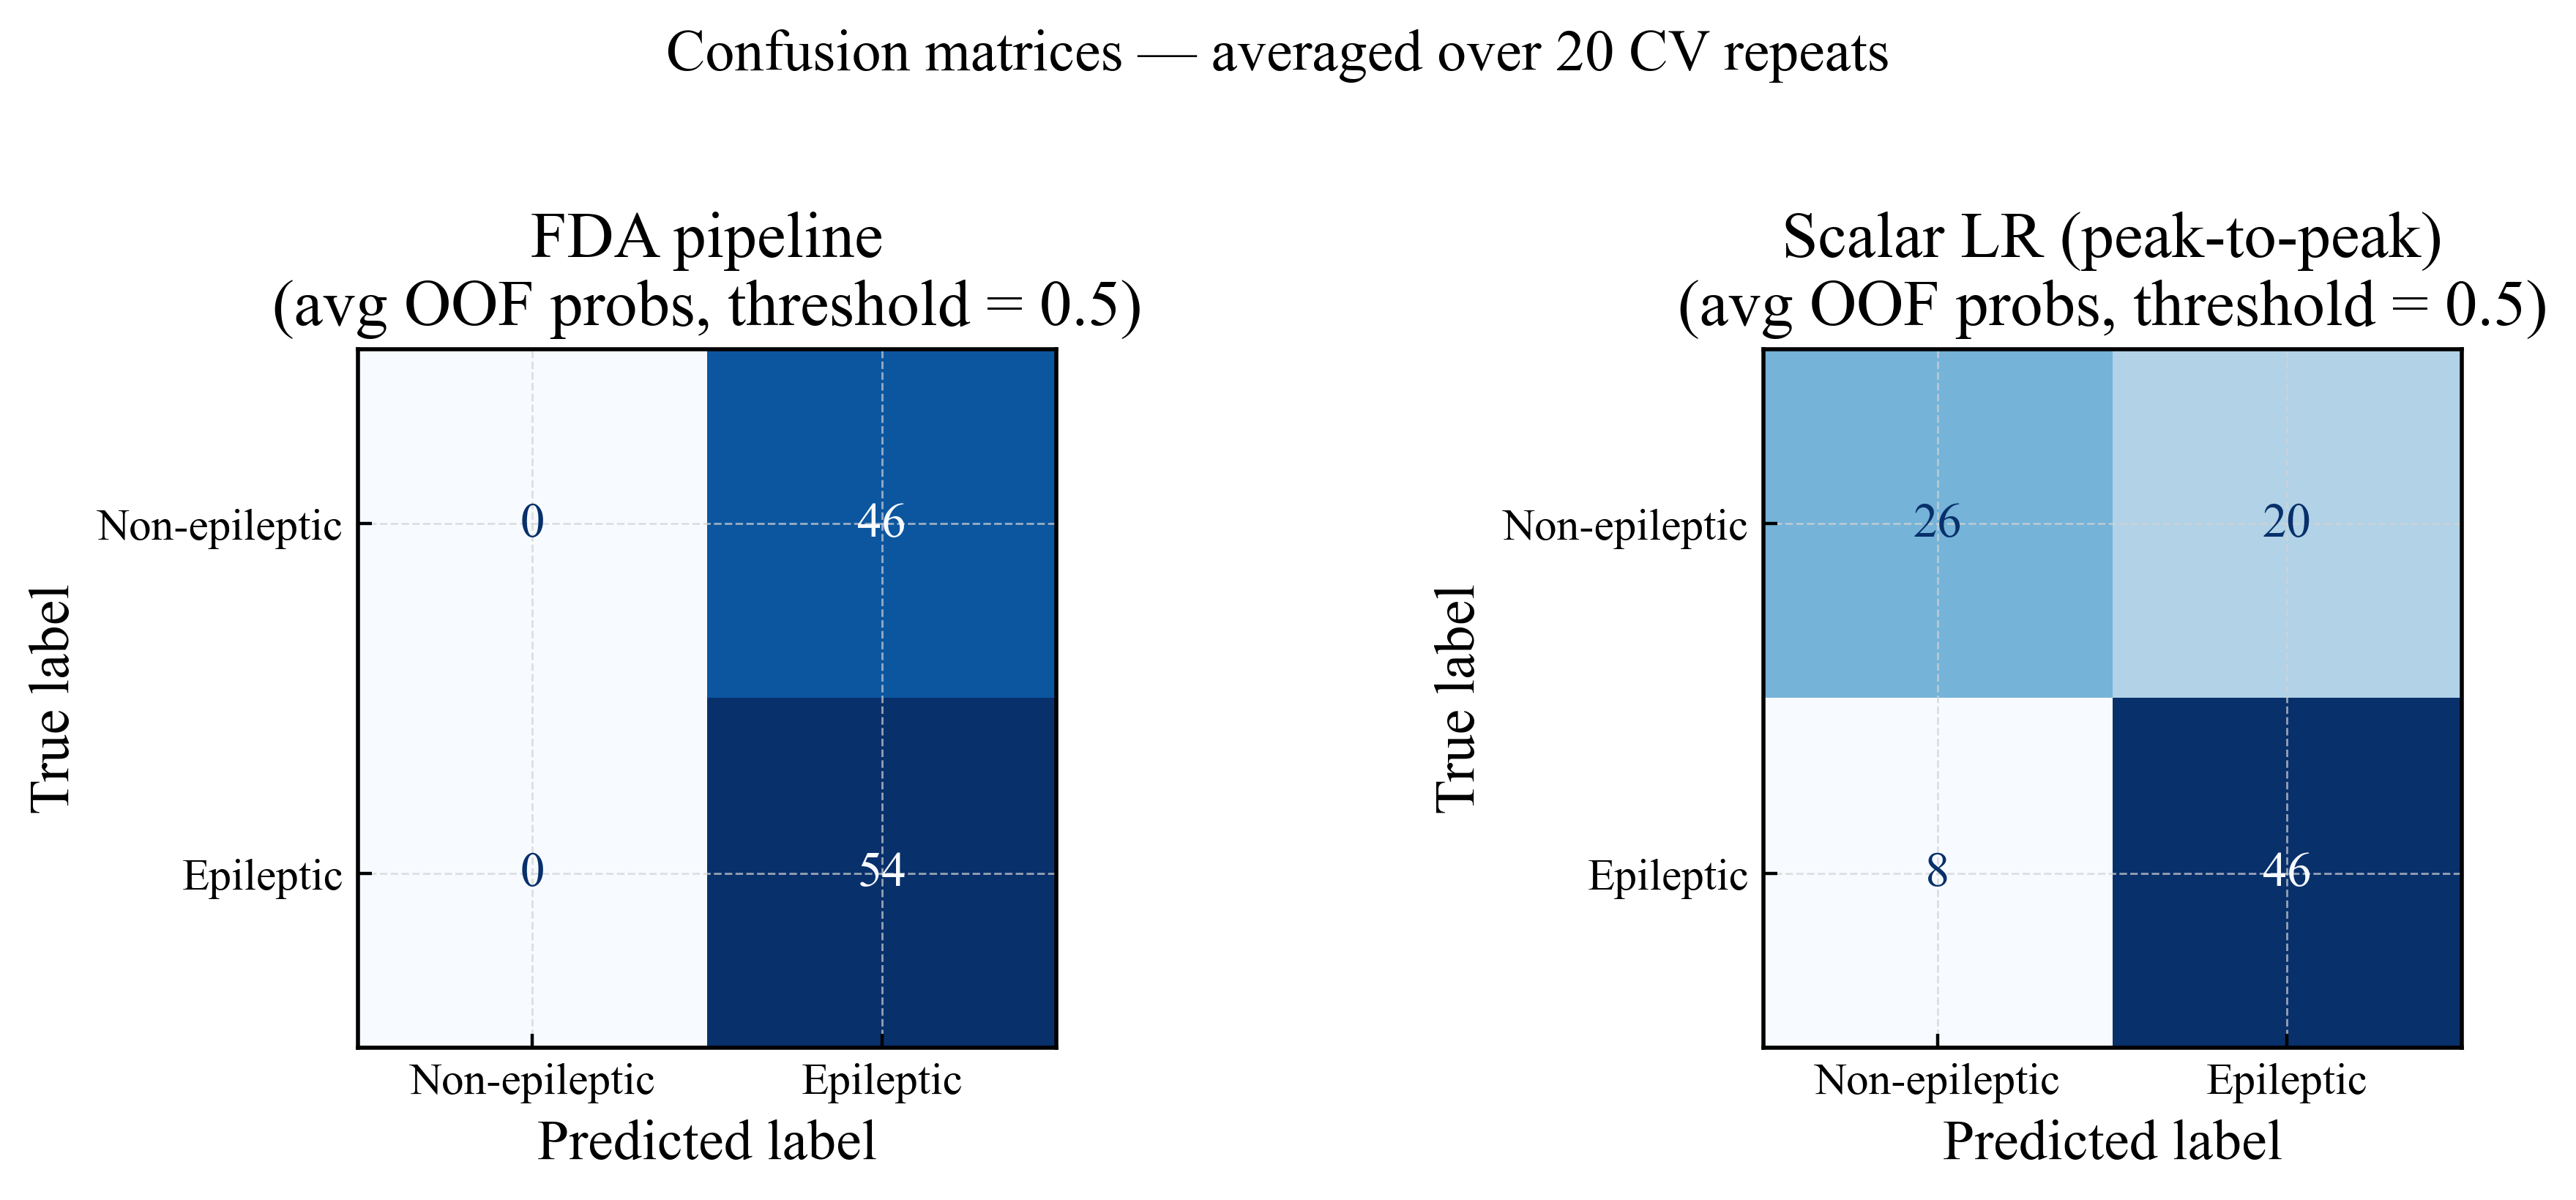

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models_cm = {
    'FDA pipeline':           avg_probs['fda'],
    'Scalar LR (peak-to-peak)': avg_probs['scalar'],
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (title, probs) in zip(axes, models_cm.items()):
    y_pred = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-epileptic', 'Epileptic'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\n(avg OOF probs, threshold = 0.5)')

plt.suptitle('Confusion matrices — averaged over 20 CV repeats', y=1.02)
plt.tight_layout()
plt.show()

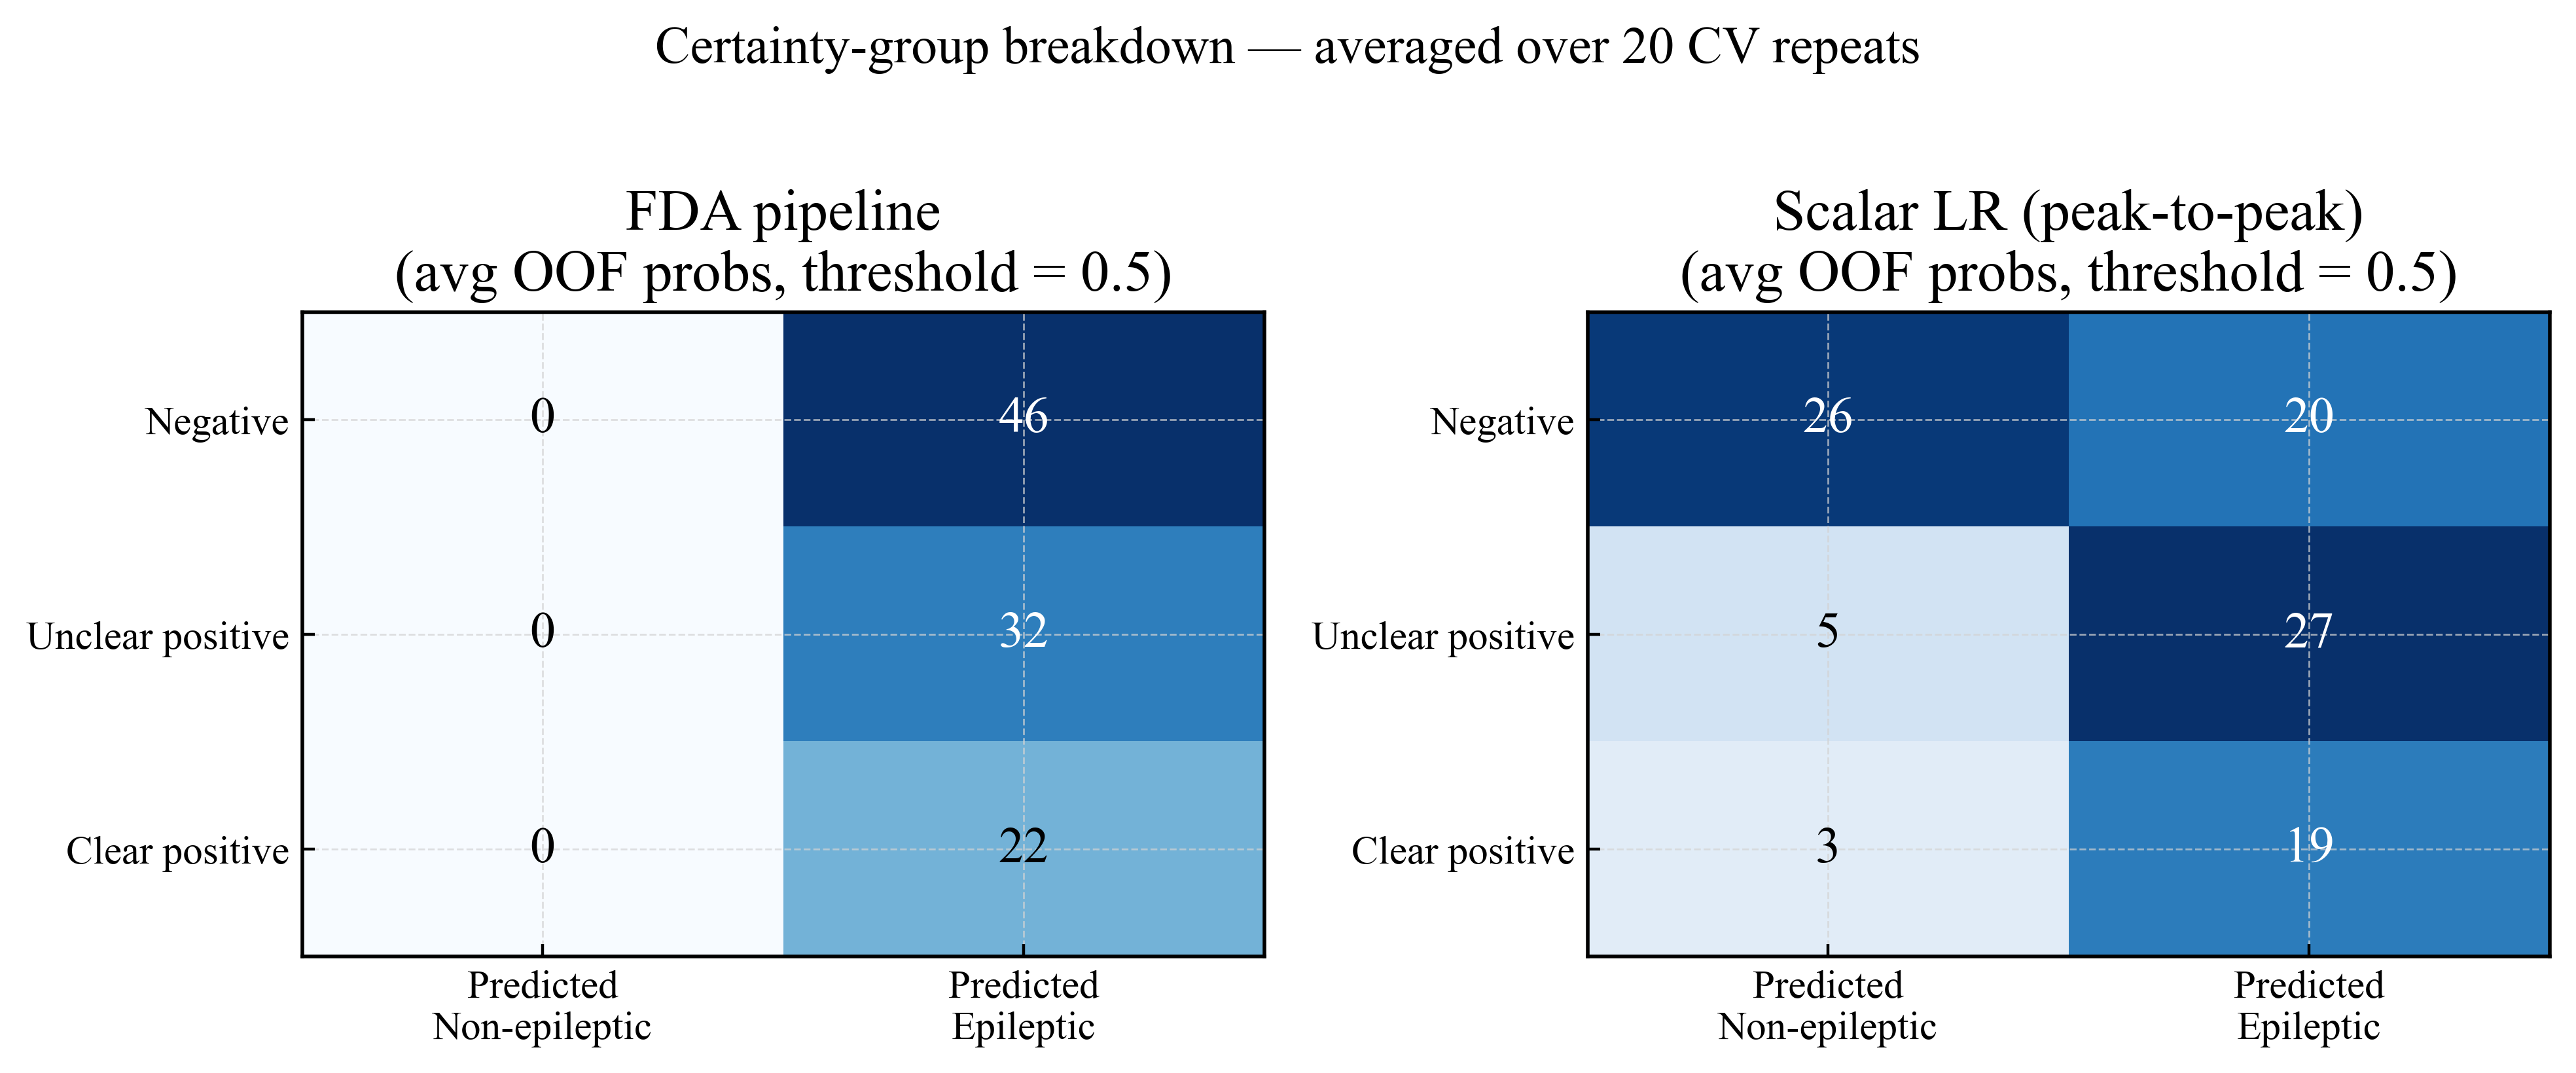

In [14]:
group_order  = ['negative', 'unclear_positive', 'clear_positive']
group_labels = ['Negative', 'Unclear positive', 'Clear positive']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (title, probs) in zip(axes, models_cm.items()):
    y_pred = (probs >= 0.5).astype(int)
    cm = np.array([
        [np.sum((cert == g) & (y_pred == 0)), np.sum((cert == g) & (y_pred == 1))]
        for g in group_order
    ])
    im = ax.imshow(cm, cmap='Blues', aspect='auto', vmin=0)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Predicted\nNon-epileptic', 'Predicted\nEpileptic'])
    ax.set_yticks(range(3))
    ax.set_yticklabels(group_labels)
    ax.set_title(f'{title}\n(avg OOF probs, threshold = 0.5)')
    thresh = cm.max() / 2
    for i in range(3):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                    color='white' if cm[i, j] > thresh else 'black')

plt.suptitle('Certainty-group breakdown — averaged over 20 CV repeats', y=1.02)
plt.tight_layout()
plt.show()